<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/%E1%84%89%E1%85%A2%E1%86%BC%E1%84%89%E1%85%A5%E1%86%BC%E1%84%92%E1%85%A7%E1%86%BCVLM_BLIP2_LLaVA_QwenVL_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 생성형 VLM 완전정복 - BLIP-2 / LLaVA / Qwen-VL

> **"이미지를 보고 글을 만들어내는 세 가지 AI, 깊이있게 비교 분석"**

## 🌟 이 노트북에서 배울 것

세 가지 대표적인 **생성형 Vision-Language Model**을 깊이 비교 학습합니다:

| 모델 | 한 줄 요약 | 주력 강점 |
|------|----------|----------|
| 🖼️ **BLIP-2** | "캡셔닝의 정석" | 짧고 정확한 이미지 설명 |
| 💬 **LLaVA** | "눈을 가진 ChatGPT" | 자유 대화 + 추론 |
| 🌏 **Qwen-VL** | "다국어 + 안경 낀 통역사" | 다국어 + OCR + 객체 탐지 |

## 📌 이 노트북의 특징

- ✅ **세 모델의 내부 구조** 깊이 비교 (Q-Former / Projection / Cross-Attention)
- ✅ **각 모델별 8가지 실전 응용** (캡셔닝, VQA, 대화, 추론 등)
- ✅ **같은 이미지, 세 모델 비교** 실습
- ✅ **친근한 비유 + 풍부한 시각화**
- ✅ **빈칸 채우기 실습 + 퀴즈**
- ✅ **Google Colab GPU** 환경에서 바로 실행
- ✅ **메모리 관리 팁** (Colab 무료 GPU에서 동작!)

> 💡 **참고**: CLIP과 비교하면 좋습니다.
> CLIP은 매칭/검색, 이 세 모델은 **자유로운 텍스트 생성**이 핵심!

> ⚠️ **GPU 필수**: Colab에서 **런타임 → 런타임 유형 변경 → T4 GPU**

---

## 📚 전체 목차

| 섹션 | 제목 | 내용 |
|------|------|------|
| 1 | 🛠️ 환경 설정 | 라이브러리, 이미지 준비, 메모리 관리 |
| 2 | 🤔 생성형 VLM 깊이 이해 | CLIP과의 차이, 공통 구조 |
| 3 | 🏗️ 세 모델 한눈에 비교 | 출시·구조·강점 |
| 4 | 🖼️ BLIP-2 깊이 분석 | Q-Former 비밀 |
| 5 | 🎯 BLIP-2 실전 응용 4가지 | 캡셔닝, VQA, 등 |
| 6 | 💬 LLaVA 깊이 분석 | "CLIP + LLM" 비밀 |
| 7 | 🎯 LLaVA 실전 응용 4가지 | 대화, 추론, 등 |
| 8 | 🌏 Qwen-VL 깊이 분석 | 다국어·OCR 비밀 |
| 9 | 🎯 Qwen-VL 실전 응용 4가지 | OCR, 객체탐지, 등 |
| 10 | 🔬 세 모델 동시 비교 | 같은 이미지, 다른 답 |
| 11 | 🎯 시나리오별 선택 가이드 | 의사결정 트리 |
| 12 | ⚠️ 한계와 함정 | 실전 주의사항 |
| 13 | 🎓 최종 정리 | 프로젝트 아이디어 |


---
# 1️⃣ 환경 설정

## 🛠️ 필요한 도구들

| 도구 | 역할 |
|------|------|
| `transformers` (최신) | 세 모델 모두 |
| `torch` | 계산 엔진 |
| `bitsandbytes` | 4-bit 양자화 (메모리 절약) |
| `accelerate` | GPU 로딩 최적화 |
| `Pillow` | 이미지 처리 |

## ⚠️ 메모리 관리 주의사항

세 모델을 동시에 메모리에 올리면 Colab 무료 GPU(15GB)에 안 들어가요!

**우리의 전략**:
1. 한 모델씩 차례로 로드
2. 다음 모델 로드 전 이전 모델 메모리 해제
3. 헬퍼 함수 `cleanup()` 제공

In [1]:
# 📦 라이브러리 설치
!pip install -q --upgrade transformers
!pip install -q torch torchvision pillow requests matplotlib seaborn
!pip install -q bitsandbytes accelerate sentencepiece

print("✅ 설치 완료!")

✅ 설치 완료!


In [2]:
# 📚 라이브러리 import
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import requests
from io import BytesIO
import gc

# 한글 폰트 (Colab용)
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.font_manager as fm
import numpy as np
import os

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 사용 장치: {device}")

if device.type == 'cuda':
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"💾 총 GPU 메모리: {total_mem:.1f} GB")
else:
    print("⚠️ GPU 없음 - 일부 모델은 매우 느릴 수 있어요")
    print("⚠️ 런타임 → 런타임 유형 변경 → T4 GPU 권장")

🖥️ 사용 장치: cuda
🎮 GPU: Tesla T4
💾 총 GPU 메모리: 15.6 GB


In [3]:
# 🧹 메모리 정리 헬퍼 함수 (중요!)
def cleanup_memory():
    """GPU 메모리 강제 해제"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    if torch.cuda.is_available():
        free, total = torch.cuda.mem_get_info()
        used = (total - free) / 1e9
        free_gb = free / 1e9
        print(f"💾 GPU 메모리: {used:.2f} GB 사용 / {free_gb:.2f} GB 남음")

def free_model(*models):
    """모델들을 메모리에서 제거"""
    for m in models:
        if m is not None:
            del m
    cleanup_memory()

cleanup_memory()
print("✅ 메모리 헬퍼 준비 완료!")

💾 GPU 메모리: 0.11 GB 사용 / 15.53 GB 남음
✅ 메모리 헬퍼 준비 완료!


In [4]:
# 🖼️ 이미지 헬퍼 함수
def load_image_from_url(url, timeout=10):
    """URL에서 이미지 다운로드 (Header 추가 버전)"""
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    try:
        response = requests.get(url, timeout=timeout, headers=headers)
        # 응답 상태 코드가 200(성공)인지 확인
        response.raise_for_status()

        return Image.open(BytesIO(response.content)).convert('RGB')
    except Exception as e:
        print(f"❌ 이미지 로드 실패 ({url}): {e}")
        return None

def show_images(images, titles=None, cols=4, figsize=None, suptitle=None):
    """여러 이미지를 격자로 표시"""
    if not isinstance(images, list):
        images = [images]
    n = len(images)
    rows = (n + cols - 1) // cols
    if figsize is None:
        figsize = (cols * 3.5, rows * 3.5)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1 or cols == 1:
        axes = np.array(axes).reshape(rows, cols)

    for i, ax in enumerate(axes.flatten()):
        if i < n:
            ax.imshow(images[i])
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=10)
        ax.axis('off')

    if suptitle:
        plt.suptitle(suptitle, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("✅ 이미지 헬퍼 준비 완료!")

✅ 이미지 헬퍼 준비 완료!


📥 갤러리 다운로드 중...
❌ 이미지 로드 실패 (http://farm4.staticflickr.com/3103/2496300330_8c76fb1caa_z.jpg): 429 Client Error: Too Many Requests for url: https://farm4.staticflickr.com/3103/2496300330_8c76fb1caa_z.jpg
❌ 이미지 로드 실패 (http://farm8.staticflickr.com/7353/9722325152_b28853088e_z.jpg): 429 Client Error: Too Many Requests for url: https://farm8.staticflickr.com/7353/9722325152_b28853088e_z.jpg
❌ 이미지 로드 실패 (http://farm4.staticflickr.com/3730/9223459070_9c2903d029_z.jpg): 429 Client Error: Too Many Requests for url: https://farm4.staticflickr.com/3730/9223459070_9c2903d029_z.jpg
❌ 이미지 로드 실패 (http://farm3.staticflickr.com/2627/3831719692_7c85cc0880_z.jpg): 429 Client Error: Too Many Requests for url: https://farm3.staticflickr.com/2627/3831719692_7c85cc0880_z.jpg
❌ 이미지 로드 실패 (http://farm1.staticflickr.com/47/136736229_18c5288070_z.jpg): 429 Client Error: Too Many Requests for url: https://farm1.staticflickr.com/47/136736229_18c5288070_z.jpg
❌ 이미지 로드 실패 (https://farm1.staticflickr.com/37/11420931

TypeError: Image data of dtype object cannot be converted to float

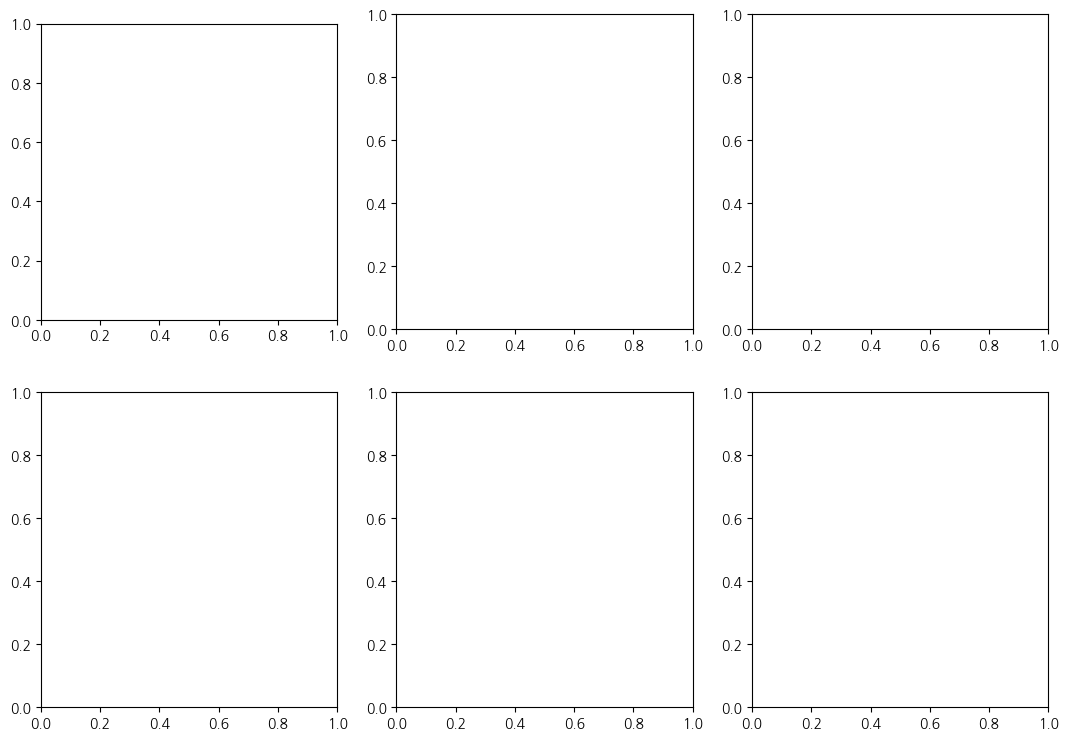

In [5]:
# 📥 실습용 이미지 갤러리 준비 (모든 섹션에서 공유)
gallery_urls = [
    ("http://farm4.staticflickr.com/3103/2496300330_8c76fb1caa_z.jpg", "cats", "동물"),
    ("http://farm8.staticflickr.com/7353/9722325152_b28853088e_z.jpg", "pizza", "음식"),
    ("http://farm4.staticflickr.com/3730/9223459070_9c2903d029_z.jpg", "airplane", "탈것"),
    ("http://farm3.staticflickr.com/2627/3831719692_7c85cc0880_z.jpg", "street", "거리"),
    ("http://farm1.staticflickr.com/47/136736229_18c5288070_z.jpg", "beach", "해변"),
    ("https://farm1.staticflickr.com/37/114209319_7e18c47176_z.jpg", "cake", "디저트"),
]

print("📥 갤러리 다운로드 중...")
gallery = {}
gallery_list = []
for url, name, _ in gallery_urls:
    img = load_image_from_url(url)
    gallery[name] = img
    gallery_list.append(img)

print(f"✅ {len(gallery)}장 로드 완료!")

# 모든 이미지 미리보기
show_images(gallery_list, titles=[f"{n[2]} ({n[1]})" for n in gallery_urls],
            cols=3, figsize=(13, 9),
            suptitle='실습용 이미지 갤러리')

### ✅ 체크포인트 1
환경 준비 + 이미지 갤러리 완료! 🎉

---
# 2️⃣ 생성형 VLM 깊이 이해하기 🤔

## 🤔 생성형 VLM이 뭔가요?

> **"이미지를 보고 자유로운 텍스트를 생성하는 AI"**

**V**ision-**L**anguage **M**odel (VLM) 중에서도 **생성(generation)** 능력이 있는 모델들.

## 🆚 CLIP과의 결정적 차이

### CLIP (매칭형)
```
🖼️ 이미지 + 📝 후보 텍스트들 → "어느 게 맞는지 골라봐"
출력: 객관식 답 (가장 잘 맞는 텍스트)
```

### 생성형 VLM
```
🖼️ 이미지 + 📝 (선택) 질문 → "자유롭게 답해봐"
출력: 새로 생성된 텍스트
```

| 항목 | CLIP | 생성형 VLM |
|------|------|----------|
| 시험 유형 | 객관식 | **주관식 / 서술형** |
| 출력 | 유사도 점수 | **자유로운 텍스트** |
| LLM 필요 | ❌ | ✅ |
| 무거움 | 가벼움 | **무거움** |
| 학습 데이터 | 4억 (이미지, 캡션) | 명령-응답 쌍 추가 |

## 🏗️ 공통 구조: 모든 생성형 VLM은 이 패턴!

```
🖼️ 이미지
   ↓
[1] Vision Encoder         ← 보통 CLIP의 ViT 사용
   ↓ 시각 특징 추출
[2] Connector / Adapter    ← 모델마다 다른 핵심 부분!
   ↓ LLM이 이해할 형태로 변환
[3] LLM (Large Language Model)  ← GPT, Llama, Qwen 등
   ↓
📝 자유로운 텍스트 응답
```

### 🎯 핵심: 모델별 차이는 [2] Connector에 있다!

| 모델 | Connector 종류 | 비유 |
|------|---------------|------|
| BLIP-2 | **Q-Former** (학습 가능한 쿼리) | 🧠 사고하는 통역사 |
| LLaVA | **Linear Projection** (단순 행렬 변환) | ➡️ 단순 어댑터 |
| Qwen-VL | **Cross-Attention + 특수 토큰** | 🌐 통합 처리기 |

이게 각 모델의 성능과 특성을 결정합니다!

In [ ]:
# 🎨 공통 구조 + 모델별 차이 시각화
fig, ax = plt.subplots(figsize=(15, 9))

# 공통 구조 (위)
# 이미지 박스
ax.add_patch(plt.Rectangle((1, 7), 1.5, 1.2, facecolor='lightyellow',
                            edgecolor='orange', linewidth=2))
ax.text(1.75, 7.6, '\n이미지', ha='center', va='center', fontsize=12)

# Vision Encoder
ax.add_patch(plt.Rectangle((3.5, 7), 2.5, 1.2, facecolor='lightblue',
                            edgecolor='blue', linewidth=2))
ax.text(4.75, 7.6, 'Vision Encoder\n(보통 CLIP-ViT)', ha='center', va='center',
        fontsize=11, fontweight='bold')

# Connector (강조)
ax.add_patch(plt.Rectangle((7, 7), 3, 1.2, facecolor='lavender',
                            edgecolor='purple', linewidth=4))
ax.text(8.5, 7.6, 'Connector\n(★ 모델별 차이!)', ha='center', va='center',
        fontsize=12, fontweight='bold', color='purple')

# LLM
ax.add_patch(plt.Rectangle((11, 7), 2.5, 1.2, facecolor='lightcoral',
                            edgecolor='red', linewidth=2))
ax.text(12.25, 7.6, 'LLM\n(GPT/Llama/Qwen)', ha='center', va='center',
        fontsize=11, fontweight='bold')

# Output
ax.add_patch(plt.Rectangle((14.5, 7), 1.5, 1.2, facecolor='lightgreen',
                            edgecolor='green', linewidth=2))
ax.text(15.25, 7.6, '\n텍스트', ha='center', va='center', fontsize=12)

# 화살표들
for x_start, x_end in [(2.5, 3.5), (6, 7), (10, 11), (13.5, 14.5)]:
    ax.annotate('', xy=(x_end, 7.6), xytext=(x_start, 7.6),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# 모델별 Connector 차이 (아래)
ax.text(8.5, 5.5, ' 모델별 Connector 비교 ', ha='center', fontsize=13,
        fontweight='bold', color='purple')

# BLIP-2
ax.add_patch(plt.Rectangle((1, 3.5), 4.5, 1.5, facecolor='#FFE4E1',
                            edgecolor='black', linewidth=2))
ax.text(3.25, 4.7, ' BLIP-2', ha='center', fontsize=12, fontweight='bold')
ax.text(3.25, 4.1, 'Q-Former\n(학습 가능한 32개 쿼리\n→ 시각→언어 압축)',
        ha='center', va='center', fontsize=10)

# LLaVA
ax.add_patch(plt.Rectangle((6, 3.5), 4.5, 1.5, facecolor='#FFEFD5',
                            edgecolor='black', linewidth=2))
ax.text(8.25, 4.7, ' LLaVA', ha='center', fontsize=12, fontweight='bold')
ax.text(8.25, 4.1, 'Linear Projection\n(단순 MLP)\n→ 시각 패치를 LLM 토큰으로',
        ha='center', va='center', fontsize=10)

# Qwen-VL
ax.add_patch(plt.Rectangle((11, 3.5), 4.5, 1.5, facecolor='#E0FFFF',
                            edgecolor='black', linewidth=2))
ax.text(13.25, 4.7, ' Qwen-VL', ha='center', fontsize=12, fontweight='bold')
ax.text(13.25, 4.1, 'Cross-Attention\n+ 특수 비전 토큰\n→ LLM 안에서 통합',
        ha='center', va='center', fontsize=10)

# 결과 비교
ax.text(3.25, 2.7, ' 효율적·가벼움', ha='center', fontsize=11, color='green')
ax.text(8.25, 2.7, ' 단순·빠른 학습', ha='center', fontsize=11, color='green')
ax.text(13.25, 2.7, ' 강력한 통합·다국어', ha='center', fontsize=11, color='green')

ax.set_xlim(0, 17)
ax.set_ylim(1.5, 9)
ax.axis('off')
plt.title(' 생성형 VLM 공통 구조 + 모델별 Connector 차이',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 3️⃣ 세 모델 한눈에 비교 🏗️

## 📊 종합 비교표

| 항목 | 🖼️ BLIP-2 | 💬 LLaVA | 🌏 Qwen-VL |
|------|----------|---------|-----------|
| **출시** | 2023.01 | 2023.04 / 1.5는 10월 | 2023.08 / Qwen2-VL은 2024 |
| **개발** | Salesforce | UW & Microsoft | Alibaba |
| **Vision Encoder** | EVA-CLIP-ViT | CLIP-ViT-L | EVA-CLIP-ViT (자체 개조) |
| **LLM** | OPT / FlanT5 | Vicuna / Llama-3 | Qwen LLM (자체) |
| **Connector** | Q-Former (32 query) | Linear / MLP | Cross-Attention |
| **사이즈** | 2.7B~12B | 7B / 13B | 2B / 7B / 72B |
| **공개 라이선스** | BSD | Apache 2.0 (1.5+) | Apache 2.0 |

## 🌟 각 모델의 핵심 강점

### 🖼️ BLIP-2
- 🥇 **이미지 캡셔닝** 최강
- 💡 **Q-Former 혁신**: 사전학습된 ViT/LLM을 그대로 두고 작은 연결 모듈만 학습
- ⚡ 가벼운 학습 (전체 4억 파라미터 학습 vs 모든 파라미터)

### 💬 LLaVA  
- 🥇 **시각 대화** 최강 (특히 1.6/1.7+ 버전)
- 💡 **단순함의 미학**: 복잡한 Q-Former 대신 단순 Projection
- 🎯 **명령 수행 학습** 강화 (GPT-4가 만든 데이터로 학습)

### 🌏 Qwen-VL
- 🥇 **OCR + 다국어** 압도적
- 🥇 **객체 위치 검출 (Grounding)** 지원
- 💡 **통합 설계**: 모든 양식(이미지/박스/텍스트)을 LLM 안에서 통합 처리

In [ ]:
# 🎨 세 모델 강점 레이더 차트
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# 카테고리
categories = ['캡셔닝', '시각 대화', '추론 능력', '다국어\n(한국어)',
              'OCR\n(글자 인식)', '객체 위치', '경량성', '생태계\n성숙도']
N = len(categories)

# 각도 (마지막에 처음으로 닫기 위해 +1)
angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 각 모델 점수 (10점 만점)
blip2_scores  = [10, 6, 6, 5, 4, 3, 9, 9]
llava_scores  = [8,  10, 9, 6, 5, 5, 6, 10]
qwen_scores   = [8,  9, 8, 9, 10, 10, 7, 8]

blip2_scores  += blip2_scores[:1]
llava_scores  += llava_scores[:1]
qwen_scores   += qwen_scores[:1]

# 그리기
ax.plot(angles, blip2_scores, 'o-', linewidth=2, label='BLIP-2', color='#FF6B9D')
ax.fill(angles, blip2_scores, alpha=0.15, color='#FF6B9D')

ax.plot(angles, llava_scores, 'o-', linewidth=2, label='LLaVA', color='#4ECDC4')
ax.fill(angles, llava_scores, alpha=0.15, color='#4ECDC4')

ax.plot(angles, qwen_scores, 'o-', linewidth=2, label='Qwen-VL', color='#FFE66D')
ax.fill(angles, qwen_scores, alpha=0.15, color='#FFE66D')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'])
ax.grid(True)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.title(' 세 모델의 강점 레이더 차트', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 BLIP-2: 캡셔닝·경량성")
print("💡 LLaVA: 대화·추론·생태계")
print("💡 Qwen-VL: OCR·다국어·객체위치")

## 🧠 퀴즈 #1

세 가지 모델의 **Connector** 부분이 다른 이유는?

- A) 단순 디자인 선택
- B) **각자의 학습 효율성과 작업 특성을 고려한 trade-off**
- C) 회사마다 라이선스가 달라서
- D) 더 새로운 게 항상 더 좋아서

<details>
<summary>👉 정답 보기</summary>

**B) 각자의 학습 효율성과 작업 특성을 고려한 trade-off**

- **BLIP-2 (Q-Former)**: 사전학습된 모델 그대로 두고 효율적 학습 → 가볍게
- **LLaVA (Linear)**: 단순한 게 더 좋다 → 명령 수행 학습에 집중
- **Qwen-VL (Cross-Attn)**: 다양한 작업(OCR/grounding)을 통합 → 강력하지만 무거움

각자 다른 설계 철학과 목표!

</details>

### ✅ 체크포인트 2

지금까지 배운 것:
- 생성형 VLM = **Vision Encoder + Connector + LLM** 구조
- **Connector**의 종류가 모델별 차이의 핵심
- BLIP-2(Q-Former) / LLaVA(Linear) / Qwen-VL(Cross-Attn)
- 각자 다른 강점 영역이 있음

다음은 **BLIP-2를 깊이 분석**해봅니다! 🖼️

---
# 4️⃣ BLIP-2 깊이 분석 🖼️

## 📖 BLIP-2 개요

> **B**ootstrapping **L**anguage-**I**mage **P**re-training **2** (Salesforce, 2023)

### 핵심 혁신: 모든 걸 새로 학습하지 말자!

이전 모델들의 문제:
- 거대한 ViT + 거대한 LLM = 전체 학습 시 천문학적 비용
- "이미 좋은 모델들이 있는데 다시 학습하는 건 낭비!"

**BLIP-2의 해결책**:
```
[ViT - 고정 (freeze)]  ← OpenAI CLIP, EVA-CLIP 등 그대로 사용
       ↓
[Q-Former - 학습]      ← 작은 연결 모듈만 학습! (약 188M)
       ↓
[LLM - 고정 (freeze)]   ← OPT, FlanT5 등 그대로 사용
```

> 💡 결과: 효율적 학습 + 좋은 성능!

## 🧠 Q-Former의 비밀

**Q**uery **Trans**former = "쿼리 기반 통역사"

### 작동 원리

1. **32개의 학습 가능한 "쿼리(Query) 토큰"** 준비
2. 이 쿼리들이 ViT 출력에 **Cross-Attention**으로 질문
3. "이 이미지에서 중요한 정보 32개만 뽑아내!"
4. 추출된 32개 임베딩 → LLM에 입력

### 🎬 비유: 면접 보는 통역사

상상해보세요. 그림을 본 사람과 글만 쓸 줄 아는 작가가 협업해요:

```
🧑‍🎨 그림 본 사람 (ViT): 256개 패치 정보를 다 보고 있음
     ↓ (너무 많은 정보)
🎤 통역사 (Q-Former): 32개 핵심 질문으로 정리
     "이게 뭐야?", "주인공은?", "배경은?", "색은?" ... 32개
     ↓ (압축된 정보)
✍️ 작가 (LLM): 32개 정보로 글 작성
```

### 🎯 왜 32개?
- 너무 적으면 정보 손실
- 너무 많으면 LLM이 헷갈림
- 실험으로 찾은 sweet spot

In [ ]:
# 🎨 Q-Former 작동 시각화
fig, ax = plt.subplots(figsize=(15, 8))

# ViT 출력 (왼쪽) - 많은 패치
n_patches = 16
for i in range(n_patches):
    y = 6 - (i // 4) * 0.8
    x = 1 + (i % 4) * 0.5
    ax.add_patch(plt.Rectangle((x, y), 0.4, 0.7, facecolor='lightblue',
                                edgecolor='blue', linewidth=1))
ax.text(2, 7.5, 'ViT 출력\n(256 패치)', ha='center', fontsize=12, fontweight='bold')
ax.text(2, 2.5, '많은 시각 정보', ha='center', fontsize=10, style='italic')

# Q-Former (가운데)
ax.add_patch(plt.Rectangle((5, 3), 3, 3, facecolor='lavender',
                            edgecolor='purple', linewidth=3))
ax.text(6.5, 5.5, 'Q-Former', ha='center', fontsize=14, fontweight='bold', color='purple')
ax.text(6.5, 5, '32개 쿼리', ha='center', fontsize=11, fontweight='bold')

# 쿼리 토큰 (작게)
for i in range(8):
    y = 4.5 - (i // 4) * 0.4
    x = 5.3 + (i % 4) * 0.6
    ax.add_patch(plt.Rectangle((x, y), 0.4, 0.3, facecolor='yellow',
                                edgecolor='orange', linewidth=1))
ax.text(6.5, 3.3, '("이게 뭐야?",\n"중요한 게 뭐야?", ...)',
        ha='center', fontsize=9, style='italic')

# 출력 (오른쪽) - 32개 압축 임베딩
for i in range(8):
    y = 6 - i * 0.5
    ax.add_patch(plt.Rectangle((10, y), 0.5, 0.4, facecolor='lightgreen',
                                edgecolor='green', linewidth=1))
ax.text(10.25, 7, '압축된 시각 정보\n(32 임베딩)', ha='center', fontsize=12, fontweight='bold')
ax.text(10.25, 2, 'LLM으로!', ha='center', fontsize=10, style='italic')

# LLM
ax.add_patch(plt.Rectangle((12.5, 3.5), 2.5, 2, facecolor='lightcoral',
                            edgecolor='red', linewidth=2))
ax.text(13.75, 4.5, 'LLM\n(OPT/FlanT5)', ha='center', va='center', fontsize=12, fontweight='bold')

# 화살표
ax.annotate('', xy=(5, 4.5), xytext=(3.2, 4.5),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.annotate('', xy=(10, 4.5), xytext=(8, 4.5),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))
ax.annotate('', xy=(12.5, 4.5), xytext=(10.5, 4.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))

# 주석
ax.text(4.1, 4.8, 'Cross\nAttention', ha='center', fontsize=9, color='blue')
ax.text(9, 4.8, '추출!', ha='center', fontsize=10, color='purple', fontweight='bold')

ax.set_xlim(0, 16)
ax.set_ylim(1, 8.5)
ax.axis('off')
plt.title(' Q-Former: 256개 패치 → 32개 핵심 임베딩으로 압축',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Q-Former 덕분에 거대한 ViT/LLM은 그대로 두고 188M 파라미터만 학습")
print("💡 정보 압축 + 효율 + 성능을 모두 잡은 설계!")

In [ ]:
# 🔧 BLIP-2 모델 로드 (메모리 관리에 주의!)
# 실제 BLIP-2 (Salesforce/blip2-opt-2.7b)는 5GB+ 무거움
# Colab 무료에서도 동작하도록 BLIP을 메인으로 사용 + BLIP-2도 옵션 제공

from transformers import BlipProcessor, BlipForConditionalGeneration

print("📥 BLIP 모델 로드 중... (BLIP-2와 사용법 거의 동일)")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)
blip_model.eval()

total_params = sum(p.numel() for p in blip_model.parameters())
print(f"✅ BLIP 로드 완료!")
print(f"📊 파라미터: {total_params:,} ({total_params/1e6:.0f}M)")

cleanup_memory()

> 💡 **BLIP-2를 직접 쓰고 싶다면?**
>
> ```python
> from transformers import Blip2Processor, Blip2ForConditionalGeneration
>
> processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
> model = Blip2ForConditionalGeneration.from_pretrained(
>     "Salesforce/blip2-opt-2.7b",
>     torch_dtype=torch.float16,
>     device_map="auto"
> )
> ```
>
> 사용법은 본 노트북의 BLIP과 거의 동일! (성능은 더 좋음)
> 단, **5GB+ 다운로드**가 필요해서 학습용으로는 BLIP을 사용합니다.

---
# 5️⃣ BLIP-2 실전 응용 4가지 🎯

## 응용 ① 무조건부 이미지 캡셔닝

> **"이미지만 주면 자동으로 설명문 생성"**

### 실전 활용 예시
- 📷 SNS 자동 alt-text 생성 (시각장애인 접근성)
- 🛒 상품 자동 설명 생성
- 📚 사진 라이브러리 자동 메타데이터
- 🎨 AI 모델 학습 데이터 캡션 자동화

In [ ]:
# 🎯 응용 1: 무조건부 캡셔닝 함수
def caption_image_blip(image, model, processor, device, prompt=None, max_length=50):
    """BLIP 이미지 캡셔닝"""
    if prompt:
        inputs = processor(image, prompt, return_tensors='pt').to(device)
    else:
        inputs = processor(image, return_tensors='pt').to(device)

    with torch.no_grad():
        output = model.generate(**inputs, max_length=max_length,
                                 num_beams=3, early_stopping=True)

    return processor.decode(output[0], skip_special_tokens=True)

# 갤러리 전체에 자동 캡션 생성
print("🎯 갤러리 자동 캡셔닝")
print("=" * 60)
captions = {}
for name, img in gallery.items():
    cap = caption_image_blip(img, blip_model, blip_processor, device)
    captions[name] = cap
    print(f"  📸 [{name}]: \"{cap}\"")

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, img) in zip(axes.flatten(), gallery.items()):
    ax.imshow(img)
    ax.set_title(f'"{captions[name]}"', fontsize=10, wrap=True)
    ax.axis('off')
plt.suptitle(' 응용 ①: 자동 캡셔닝 결과', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 응용 ② 조건부 캡셔닝 (프롬프트 기반)

> **"시작 문구를 주면 그것을 이어서 캡션 생성"**

### 활용
- 특정 스타일·관점의 캡션 생성
- 빠진 정보 추가 요청
- 도메인 특화 설명

In [ ]:
# 🎯 응용 2: 조건부 캡셔닝
target_img = gallery['cats']
show_images(target_img, ["조건부 캡셔닝 대상"], cols=1, figsize=(5, 4))

# 다양한 프롬프트로 시도
prompts = [
    "a photograph of",
    "this image shows",
    "in this picture, there are",
    "the cats are",
    "a close-up view of",
    "an artistic photo featuring",
]

print("🎯 같은 이미지, 다른 시작 문구")
print("=" * 60)
results = []
for prompt in prompts:
    caption = caption_image_blip(target_img, blip_model, blip_processor, device, prompt=prompt)
    results.append((prompt, caption))
    print(f"\n📝 '{prompt}'")
    print(f"   → {caption}")

In [ ]:
# 🎨 조건부 캡션 비교 시각화
fig, ax = plt.subplots(figsize=(14, 5))

prompts_list = [r[0] for r in results]
captions_list = [r[1] for r in results]

y_pos = np.arange(len(prompts_list))
ax.barh(y_pos, [len(c) for c in captions_list], color='steelblue', alpha=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'"{p}..."' for p in prompts_list], fontsize=10)

for i, (prompt, cap) in enumerate(results):
    ax.text(2, i, cap, va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('캡션 길이 (문자 수)')
ax.set_title(' 프롬프트에 따라 달라지는 캡션 스타일', fontsize=13, fontweight='bold')
ax.set_xlim(0, max([len(c) for c in captions_list]) + 5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 응용 ③ 시각적 질문 답변 (Visual QA)

> **"이미지에 대한 구체적 질문에 답하기"**

### 활용
- 챗봇이 사용자 사진을 분석
- 교육: "이 그림에 무엇이 있나요?" 같은 학습 문제
- 시각장애인 보조

In [ ]:
# 🎯 응용 3: VQA (Question을 prompt로 활용)
def vqa_blip(image, question, model, processor, device, max_length=30):
    """BLIP으로 시각 질문 답변"""
    # BLIP은 질문을 prompt에 포함시키는 방식
    prompt = f"Question: {question} Answer:"
    inputs = processor(image, prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        output = model.generate(**inputs, max_length=max_length,
                                 num_beams=3, early_stopping=True)

    answer = processor.decode(output[0], skip_special_tokens=True)
    # 질문 부분 제거
    if "Answer:" in answer:
        answer = answer.split("Answer:")[-1].strip()
    return answer

# 여러 이미지에 다양한 질문
qa_tests = [
    ('cats', "How many cats are in this image?"),
    ('cats', "What color are the cats?"),
    ('cats', "Where are the cats?"),
    ('pizza', "What kind of food is this?"),
    ('pizza', "What toppings does it have?"),
    ('beach', "What kind of place is this?"),
    ('airplane', "What is in the sky?"),
]

print("🎯 응용 ③: 시각 질문 답변 (VQA)")
print("=" * 60)
for img_name, question in qa_tests:
    answer = vqa_blip(gallery[img_name], question, blip_model, blip_processor, device)
    print(f"\n📸 [{img_name}]")
    print(f"  👤 Q: {question}")
    print(f"  🤖 A: {answer}")

## 응용 ④ 이미지-텍스트 검색 (BLIP의 또 다른 능력)

> **"BLIP-2는 캡셔닝 외에도 CLIP처럼 검색에도 강함"**

BLIP-2의 Q-Former는 학습 시 **3가지 목표**로 동시 학습되었어요:
1. 이미지-텍스트 매칭 (CLIP 스타일)
2. 이미지-텍스트 대조 학습
3. 이미지 캡셔닝

→ 그래서 검색에도 쓸 수 있어요!

In [ ]:
# 🎯 응용 4: BLIP 기반 이미지-텍스트 매칭
# (BLIP은 caption만 가능하지만, 응용으로 캡션 → CLIP 비교 가능)
# 여기서는 캡션 기반 매칭 점수로 구현

from transformers import BlipForImageTextRetrieval, BlipProcessor as BlipITRProcessor

print("📥 BLIP 검색 모델 로드 중...")
blip_itr_processor = BlipITRProcessor.from_pretrained("Salesforce/blip-itm-base-coco")
blip_itr_model = BlipForImageTextRetrieval.from_pretrained("Salesforce/blip-itm-base-coco").to(device)
blip_itr_model.eval()
print("✅ 로드 완료!")

def image_text_match_blip(image, text, model, processor, device):
    """BLIP으로 이미지-텍스트 매칭 점수"""
    inputs = processor(image, text, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        # ITM score: 매칭 확률
        itm_score = torch.softmax(outputs.itm_score, dim=-1)[:, 1].item()
    return itm_score

# 매칭 테스트
test_image = gallery['cats']
test_texts = [
    "two cats sleeping on a bed",   # 정확
    "a couple of cats lying down",   # 비슷
    "a dog running in the park",     # 다름
    "pizza on a table",               # 완전 다름
    "cats and dogs",                  # 부분 일치
]

print("\n🎯 응용 ④: 이미지-텍스트 매칭 점수")
print("=" * 60)
print(f"🖼️ 이미지: 고양이 두 마리\n")
for text in test_texts:
    score = image_text_match_blip(test_image, text, blip_itr_model, blip_itr_processor, device)
    bar = "█" * int(score * 40)
    print(f"  {score:.4f} {bar}  '{text}'")

## 🎯 빈칸 채우기 실습 #1

여러분만의 이미지로 BLIP을 활용해보세요!

In [ ]:
# 🎯 실습 #1: BLIP으로 직접 캡션 + VQA
my_image = gallery['airplane']
show_images(my_image, ["분석할 이미지"], cols=1, figsize=(5, 4))

# TODO: 1. 자동 캡션 생성 (조건 없이)
auto_caption = caption_image_blip(my_image, blip_model, blip_processor, device)

# TODO: 2. 조건부 캡션 (prompt="a photograph capturing")
prompt_caption = caption_image_blip(my_image, blip_model, blip_processor, device,
                                      prompt="a photograph capturing")

# TODO: 3. VQA 질문 만들기
my_question = "What can you see in the sky?"
qa_answer = vqa_blip(my_image, my_question, blip_model, blip_processor, device)

print(f"📸 분석 결과:")
print(f"\n🤖 자동 캡션: {auto_caption}")
print(f"🤖 조건부 캡션: {prompt_caption}")
print(f"\n👤 Q: {my_question}")
print(f"🤖 A: {qa_answer}")

<details>
<summary>🔑 정답 보기</summary>

```python
auto_caption = caption_image_blip(my_image, blip_model, blip_processor, device)
prompt_caption = caption_image_blip(my_image, blip_model, blip_processor, device,
                                      prompt="a photograph capturing")
qa_answer = vqa_blip(my_image, my_question, blip_model, blip_processor, device)
```

- `device` 전달
- `prompt` 매개변수에 시작 문구 전달
- `vqa_blip` 함수 사용

</details>

## 🧠 퀴즈 #2

BLIP-2의 **Q-Former**의 가장 큰 장점은?

- A) ViT와 LLM을 함께 학습한다
- B) **무거운 ViT/LLM은 고정하고 작은 모듈만 학습 → 효율적**
- C) 한국어를 잘 지원한다
- D) GPU 없이 작동한다

<details>
<summary>👉 정답 보기</summary>

**B) 무거운 ViT/LLM은 고정하고 작은 모듈만 학습 → 효율적**

Q-Former의 천재적 설계:
- 사전학습된 거대 ViT는 그대로 (학습 안 함)
- 사전학습된 거대 LLM도 그대로 (학습 안 함)
- 188M짜리 Q-Former만 학습
- 결과: 적은 자원으로 좋은 성능!

이런 "어댑터 기반" 접근법은 LoRA, P-tuning 같은 최신 PEFT 기법의 시조 격이에요.

</details>

### ✅ 체크포인트 3 - BLIP-2 마스터!

🎉 BLIP-2 깊이 학습 완료! 배운 것:
- **Q-Former**: 32개 쿼리로 시각 정보 압축
- **무거운 모델 고정 + 작은 모듈만 학습**의 효율성
- 4가지 응용: 캡셔닝(무조건/조건) + VQA + 이미지-텍스트 매칭

> 🧹 다음 모델 로드 전에 BLIP 메모리 정리!

In [ ]:
# 🧹 BLIP 모델 메모리 정리 (LLaVA 로드 전 필수!)
free_model(blip_model, blip_processor, blip_itr_model, blip_itr_processor)
print("✅ BLIP 메모리 해제 완료, LLaVA 로드 준비!")

---
# 6️⃣ LLaVA 깊이 분석 💬

## 📖 LLaVA 개요

> **L**arge **L**anguage **a**nd **V**ision **A**ssistant (UW & Microsoft, 2023)

### 핵심 철학: 단순함이 곧 힘

BLIP-2가 "복잡한 Q-Former"라면, LLaVA는 **"가장 단순한 연결"**:

```
[CLIP Vision Encoder] (고정)
    ↓ 576개 패치 벡터
[Linear / 2-layer MLP] (학습)    ← 단순한 행렬 변환만!
    ↓ LLM 토큰 차원으로 변환
[Llama / Vicuna LLM] (전체 또는 일부 학습)
    ↓
📝 응답
```

> 💡 BLIP-2의 Q-Former는 "사고하는 통역사"
> 💡 LLaVA의 Linear는 **"단순 어댑터"** - 그냥 차원만 맞춰주는 변환기

## 🤔 왜 단순한 게 더 좋을 수 있나?

LLaVA 연구진의 주장:
- 시각 정보의 **압축은 손실**을 가져온다
- LLM이 충분히 똑똑하다면, 모든 패치 정보를 그대로 받는 게 좋다
- "압축하지 말고 LLM에 맡기자"

**결과**: LLaVA-1.5+에서는 BLIP-2보다 대화·추론 능력에서 우수한 성능

## 🏗️ LLaVA의 입력 처리 흐름

### 비유: 면접관에게 사진 + 질문 동시에 보여주기

```
1. 시각 정보 변환
   🖼️ 이미지 → CLIP → 576 패치 임베딩 (1024차원)
        ↓ Linear/MLP
        576 패치 임베딩 (LLM 차원, 보통 4096)

2. 텍스트 토큰화
   "What's in this image?" → 토큰화 → 토큰 IDs

3. 시각 + 텍스트 결합 (특수 토큰 <image>)
   [<image>] [What] ['s] [in] [this] [image] [?]
      ↓
   [576 시각 임베딩] [텍스트 토큰들]

4. LLM이 통째로 처리
   → 응답 생성
```

In [ ]:
# 🎨 LLaVA vs BLIP-2 입력 처리 비교
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# BLIP-2 (위)
ax = axes[0]
ax.text(0.5, 0.92, ' BLIP-2: Q-Former로 정보 압축', ha='center',
        fontsize=14, fontweight='bold', transform=ax.transAxes, color='purple')

# 576 → 32 압축 표현
for i in range(15):  # 576을 15개로 표현
    ax.add_patch(plt.Rectangle((1 + i*0.5, 0.4), 0.4, 0.4,
                                facecolor='lightblue', edgecolor='blue', linewidth=1))
ax.text(4.5, 0.7, '576 시각 임베딩', ha='center', fontsize=10)

ax.annotate('', xy=(11, 0.6), xytext=(8.5, 0.6),
            arrowprops=dict(arrowstyle='->', color='purple', lw=3))
ax.text(9.75, 0.7, 'Q-Former\n(압축)', ha='center', fontsize=10, color='purple')

# 32개만 표현 (간략하게 5개)
for i in range(5):
    ax.add_patch(plt.Rectangle((11 + i*0.5, 0.4), 0.4, 0.4,
                                facecolor='lightyellow', edgecolor='orange', linewidth=2))
ax.text(12, 0.7, '32 압축 토큰', ha='center', fontsize=10, color='orange', fontweight='bold')

# LLM
ax.add_patch(plt.Rectangle((14, 0.3), 1.5, 0.6, facecolor='lightcoral',
                            edgecolor='red', linewidth=2))
ax.text(14.75, 0.6, 'LLM', ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 16)
ax.set_ylim(0, 1)
ax.axis('off')

# LLaVA (아래)
ax = axes[1]
ax.text(0.5, 0.92, ' LLaVA: 단순 Projection으로 그대로 전달', ha='center',
        fontsize=14, fontweight='bold', transform=ax.transAxes, color='green')

# 576 그대로
for i in range(15):
    ax.add_patch(plt.Rectangle((1 + i*0.5, 0.4), 0.4, 0.4,
                                facecolor='lightblue', edgecolor='blue', linewidth=1))
ax.text(4.5, 0.7, '576 시각 임베딩', ha='center', fontsize=10)

ax.annotate('', xy=(11, 0.6), xytext=(8.5, 0.6),
            arrowprops=dict(arrowstyle='->', color='green', lw=3))
ax.text(9.75, 0.7, 'Linear/MLP\n(차원만 변환)', ha='center', fontsize=10, color='green')

# 576 그대로 (15개)
for i in range(15):
    ax.add_patch(plt.Rectangle((11 + i*0.18, 0.4), 0.15, 0.4,
                                facecolor='lightgreen', edgecolor='darkgreen', linewidth=1))
ax.text(12.2, 0.7, '576 임베딩\n(LLM 차원)', ha='center', fontsize=10, color='darkgreen', fontweight='bold')

# LLM
ax.add_patch(plt.Rectangle((14, 0.3), 1.5, 0.6, facecolor='lightcoral',
                            edgecolor='red', linewidth=2))
ax.text(14.75, 0.6, 'LLM', ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 16)
ax.set_ylim(0, 1)
ax.axis('off')

plt.suptitle(' BLIP-2 vs LLaVA: 시각 정보 처리 방식 차이',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 BLIP-2: 정보 압축 → 효율적, 가벼움")
print("💡 LLaVA: 정보 보존 → 자세한 분석, 추론 강함")

## 🎓 LLaVA의 학습 비법: GPT-4가 만든 데이터

LLaVA의 또 다른 혁신!

### 1단계: 시각-텍스트 정렬 (Linear만 학습)
- COCO 등의 (이미지, 캡션) 데이터로 정렬

### 2단계: 명령 수행 학습 (전체 학습)
- **GPT-4로 158K개 시각 명령 데이터 자동 생성!**
- "이 이미지를 분석해서 다음 질문에 답해주세요" 식의 데이터
- GPT-4의 추론·대화 패턴을 LLaVA가 따라함

### 🤖 비유: 학생 → 명문 학교 졸업생을 따라하기
- BLIP-2: 기본기 학습
- LLaVA: GPT-4(우등생)의 답안을 그대로 보고 배움 → 영리한 응답 패턴 습득

---
# 7️⃣ LLaVA 실전 응용 4가지 🎯

> ⚠️ **메모리 주의**: LLaVA-1.5-7B는 fp16에서 14GB+
> 4-bit 양자화로 ~5GB로 줄여서 사용합니다.

In [ ]:
# 🔧 LLaVA 로드 (4-bit 양자화)
from transformers import LlavaProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

llava_model_name = "llava-hf/llava-1.5-7b-hf"

# 4-bit 양자화 설정
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print("📥 LLaVA-1.5-7B 로드 중... (4-bit, ~5분)")
llava_processor = LlavaProcessor.from_pretrained(llava_model_name)
llava_model = LlavaForConditionalGeneration.from_pretrained(
    llava_model_name,
    quantization_config=quant_config,
    device_map="auto",
)
llava_model.eval()

print(f"✅ LLaVA-1.5-7B 로드 완료!")
print(f"💾 4-bit 양자화로 메모리 ~5GB")
cleanup_memory()

In [ ]:
# 💬 LLaVA 대화 함수
def chat_llava(image, question, model, processor, max_new_tokens=200, temperature=0.2):
    """LLaVA와 이미지 대화"""
    prompt = f"USER: <image>\n{question}\nASSISTANT:"

    inputs = processor(images=image, text=prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=(temperature > 0),
            temperature=temperature,
            pad_token_id=processor.tokenizer.pad_token_id or processor.tokenizer.eos_token_id,
        )

    response = processor.decode(output[0], skip_special_tokens=True)
    answer = response.split("ASSISTANT:")[-1].strip()
    return answer

print("✅ 대화 함수 준비 완료!")

## 응용 ① 자세한 이미지 설명

> **"BLIP-2가 한 문장 캡션이라면, LLaVA는 문단급 설명"**

LLaVA는 자세하고 구조적인 설명에 강해요!

In [ ]:
# 🎯 응용 1: 자세한 이미지 설명
target_img = gallery['street']
show_images(target_img, ["분석 대상"], cols=1, figsize=(5, 4))

# 단순 캡션 → 자세한 분석으로 확장
detail_questions = [
    "Briefly describe this image.",
    "Describe this image in detail, including objects, colors, and atmosphere.",
    "Write a detailed paragraph describing everything you see in this image.",
]

print("🎯 응용 ①: 점진적으로 자세한 설명 요청")
print("=" * 70)
for q in detail_questions:
    answer = chat_llava(target_img, q, llava_model, llava_processor, max_new_tokens=200)
    print(f"\n👤 Q: {q}")
    print(f"🤖 A: {answer}")
    print(f"   (응답 길이: {len(answer)}자)")

## 응용 ② 시각적 추론 (Visual Reasoning)

> **"단순 분류가 아닌, 보고 생각해서 답하기"**

이게 LLaVA의 진정한 가치! BLIP-2로는 어려운 작업입니다.

### 추론 작업 유형
- 인과 관계: "왜 이런 상황이 됐을까?"
- 시간/시점: "이 사진은 언제 찍힌 것 같아?"
- 분석/평가: "이 장면의 문제점은?"
- 상상/창작: "이 사람의 생각은?"

In [ ]:
# 🎯 응용 2: 다양한 추론 작업
test_img = gallery['cake']
show_images(test_img, ["디저트 사진"], cols=1, figsize=(5, 4))

reasoning_qs = [
    "What occasion might this dessert be for?",
    "How would you describe the presentation? Is it casual or formal?",
    "If you could taste this, what flavors do you imagine?",
    "What might be the next step if you were eating this?",
]

print("🎯 응용 ②: LLaVA의 시각 추론 능력")
print("=" * 70)
for q in reasoning_qs:
    answer = chat_llava(test_img, q, llava_model, llava_processor, max_new_tokens=120)
    print(f"\n👤 Q: {q}")
    print(f"🤖 A: {answer}")

## 응용 ③ 멀티턴 대화 (Multi-turn Conversation)

> **"한 이미지를 두고 여러 번 주고받는 대화"**

이게 진정한 "시각 채팅봇"!

### 대화 흐름 관리
- 이전 대화 맥락을 LLaVA에게 전달
- "이미지 + 대화 히스토리 + 새 질문" 입력

In [ ]:
# 🎯 응용 3: 멀티턴 대화 시스템
class LLaVAChat:
    """LLaVA 기반 멀티턴 대화"""

    def __init__(self, model, processor):
        self.model = model
        self.processor = processor
        self.image = None
        self.history = []  # [(role, message), ...]

    def set_image(self, image):
        self.image = image
        self.history = []
        print("🖼️ 새 이미지 설정. 대화 시작!")

    def chat(self, user_message, max_new_tokens=200):
        if self.image is None:
            return "❌ 먼저 set_image()로 이미지를 설정하세요."

        # 프롬프트 구성: 히스토리 포함
        prompt = "USER: <image>\n"
        for i, (role, msg) in enumerate(self.history):
            if i == 0 and role == 'USER':
                prompt += f"{msg}\nASSISTANT:"
            elif role == 'USER':
                prompt += f"\nUSER: {msg}\nASSISTANT:"
            else:
                prompt += f" {msg}"

        # 새 질문 추가
        if self.history:
            prompt += f"\nUSER: {user_message}\nASSISTANT:"
        else:
            prompt += f"{user_message}\nASSISTANT:"

        inputs = self.processor(images=self.image, text=prompt,
                                return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            output = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=self.processor.tokenizer.eos_token_id,
            )

        response = self.processor.decode(output[0], skip_special_tokens=True)
        # 가장 마지막 ASSISTANT 부분 추출
        answer = response.split("ASSISTANT:")[-1].strip()

        # 히스토리 업데이트
        self.history.append(('USER', user_message))
        self.history.append(('ASSISTANT', answer))

        return answer

# 챗봇 생성 & 시연
chat = LLaVAChat(llava_model, llava_processor)
chat.set_image(gallery['beach'])
show_images(gallery['beach'], ["대화 대상 이미지"], cols=1, figsize=(5, 4))

# 멀티턴 대화 시연
turns = [
    "What do you see in this image?",
    "What time of day do you think it is?",
    "If I wanted to visit a place like this, where would you recommend?",
    "What should I bring with me to this place?",
]

print("\n💬 멀티턴 대화 시뮬레이션")
print("=" * 70)
for q in turns:
    reply = chat.chat(q, max_new_tokens=120)
    print(f"\n👤 You: {q}")
    print(f"🤖 LLaVA: {reply}")

## 응용 ④ 구조화된 정보 추출

> **"이미지에서 JSON/리스트 형태로 정보 추출"**

실전 응용에서 매우 중요! 후속 시스템과 연동하기 좋아요.

### 활용
- 자동 메타데이터 생성
- DB 입력 자동화
- API 응답 구조화

In [ ]:
# 🎯 응용 4: 구조화된 정보 추출
def extract_structured(image, model, processor):
    """이미지에서 JSON 형식 정보 추출"""
    structured_prompt = '''Analyze this image and respond ONLY in this exact JSON format:
{
  "main_subject": "<single phrase>",
  "objects": ["<obj1>", "<obj2>", ...],
  "colors": ["<color1>", "<color2>", ...],
  "scene_type": "<indoor or outdoor>",
  "mood": "<one word>",
  "time_of_day": "<one of: morning/afternoon/evening/night/unknown>",
  "estimated_count": <number of main subjects>
}'''

    return chat_llava(image, structured_prompt, model, processor,
                       max_new_tokens=300, temperature=0.1)

# 테스트
print("🎯 응용 ④: 구조화된 정보 추출")
print("=" * 70)

for name in ['cats', 'pizza', 'street']:
    img = gallery[name]
    print(f"\n📸 이미지: [{name}]")
    print("-" * 50)
    result = extract_structured(img, llava_model, llava_processor)
    print(result)

## 🎯 빈칸 채우기 실습 #2

LLaVA로 직접 시각 추론을 해보세요!

In [ ]:
# 🎯 실습 #2: LLaVA 시각 추론
my_image = gallery['pizza']
show_images(my_image, ["피자 사진"], cols=1, figsize=(5, 4))

# TODO: 1. 자세한 묘사 요청 (max_new_tokens=200)
detail = chat_llava(my_image, "Describe this dish in detail.",
                    llava_model, llava_processor, max_new_tokens=200)

# TODO: 2. 분석 질문하기
my_question = "What kind of cuisine is this and what country might it originate from?"
analysis = chat_llava(my_image, my_question, llava_model, llava_processor, max_new_tokens=150)

# TODO: 3. 창의적 질문하기
creative_q = "Write a short menu description that would make me want to order this."
creative = chat_llava(my_image, creative_q, llava_model, llava_processor, max_new_tokens=150)

print("📝 자세한 묘사:")
print(detail)
print("\n🧠 문화/원산지 분석:")
print(analysis)
print("\n✍️ 메뉴 설명 (창작):")
print(creative)

<details>
<summary>🔑 정답 보기</summary>

```python
detail = chat_llava(my_image, "Describe this dish in detail.",
                    llava_model, llava_processor, max_new_tokens=200)

analysis = chat_llava(my_image, my_question, llava_model, llava_processor, max_new_tokens=150)

creative = chat_llava(my_image, creative_q, llava_model, llava_processor, max_new_tokens=150)
```

- LLaVA는 묘사 → 분석 → 창작 모두 가능!
- 같은 이미지에 대해 다양한 질문 유형을 시도해보세요

</details>

## 🧠 퀴즈 #3

LLaVA-1.5의 학습에서 가장 중요한 혁신은?

- A) 더 큰 ViT를 사용한다
- B) **GPT-4로 자동 생성한 시각 명령 데이터로 학습**
- C) 한국어 데이터로 추가 학습
- D) 양자화 기술

<details>
<summary>👉 정답 보기</summary>

**B) GPT-4로 자동 생성한 시각 명령 데이터로 학습**

LLaVA의 천재적 학습 방법:
1. COCO 이미지 + 캡션 → GPT-4에게 보여줌
2. GPT-4에게 "이 이미지에 대한 질문/답변 만들어줘" 요청
3. 158K개의 (이미지, 명령, 응답) 데이터 자동 생성
4. LLaVA가 이걸 학습 → GPT-4의 추론 패턴 모방

이게 LLaVA를 ChatGPT-style 대화 어시스턴트로 만든 비결!

</details>

### ✅ 체크포인트 4 - LLaVA 마스터!

🎉 LLaVA 깊이 학습 완료! 배운 것:
- **Linear/MLP Projection**: 단순함의 미학
- **GPT-4 데이터로 학습**: 추론·대화 능력 강화
- 4가지 응용: 자세한 설명 + 시각 추론 + 멀티턴 대화 + 구조화 추출

> 🧹 다음 모델(Qwen-VL) 로드 전 메모리 정리!

In [ ]:
# 🧹 LLaVA 메모리 정리 (Qwen-VL 로드 전 필수!)
free_model(llava_model, llava_processor)
del chat  # 챗봇 객체도 삭제
print("✅ LLaVA 메모리 해제 완료, Qwen-VL 로드 준비!")

---
# 8️⃣ Qwen-VL 깊이 분석 🌏

## 📖 Qwen-VL 개요

> **Qwen-VL** (Alibaba, 2023~) / 최신 버전: Qwen2-VL (2024)

### 핵심 철학: 통합 멀티모달 처리

Alibaba의 비전:
> "이미지, 텍스트, 박스 좌표 등 **모든 양식을 LLM 안에서 통합 처리**하자"

### Qwen-VL의 3가지 압도적 강점

#### 🌏 1. 다국어 (Multilingual)
- **중국어/영어 모두 강함** (특히 중국어)
- 한국어/일본어/베트남어 등 다양한 언어 지원
- 학습 데이터에 다국어 의도적 포함

#### 👓 2. OCR (Optical Character Recognition)
- **이미지 속 글자**를 매우 잘 읽음
- 손글씨, 인쇄체, 디지털 폰트 모두 OK
- 표·차트 같은 구조적 텍스트도 인식

#### 🎯 3. Visual Grounding (객체 위치)
- **"이 사진에서 강아지는 어디에 있어?"** → 좌표 반환!
- `<box>x1,y1,x2,y2</box>` 형식
- 다른 VLM과 차별화되는 독보적 기능

## 🏗️ Qwen-VL 구조의 특별함

### 일반 VLM vs Qwen-VL

| 항목 | BLIP-2 / LLaVA | Qwen-VL |
|------|---------------|---------|
| 시각 정보 처리 | 별도 connector 거침 | 직접 LLM 안으로 |
| 좌표 표현 | 없음 | **특수 토큰 `<box>`** |
| 이미지 토큰 | 일반 임베딩 | **`<img>`, `</img>` 마커** |
| 다중 이미지 | 어려움 | 쉬움 (마커로 구분) |

### 💡 통합 처리의 마법

```
입력 예시:
<img>[이미지 데이터]</img> Where is the cat?

출력 예시:
The cat is located at <box>120,80,250,200</box>
                      ↑ 좌표가 텍스트의 일부로 출력!
```

이 "토큰 통합" 설계가 OCR과 Grounding을 가능하게 합니다.

In [ ]:
# 🎨 Qwen-VL 통합 처리 시각화
fig, ax = plt.subplots(figsize=(15, 8))

# 입력 (왼쪽)
ax.text(2, 7.5, ' 입력', ha='center', fontsize=14, fontweight='bold')

# 이미지 마커로 감싼 형태
ax.add_patch(plt.Rectangle((0.5, 5.5), 3, 1.5, facecolor='lightblue',
                            edgecolor='blue', linewidth=2))
ax.text(2, 6.25, '<img>\n 이미지\n</img>', ha='center', va='center',
        fontsize=11, fontweight='bold')

# 텍스트 부분
ax.add_patch(plt.Rectangle((0.5, 3.5), 3, 1.5, facecolor='lightyellow',
                            edgecolor='orange', linewidth=2))
ax.text(2, 4.25, '"고양이는\n어디에 있어?"', ha='center', va='center', fontsize=11)

# Qwen LLM (가운데)
ax.add_patch(plt.Rectangle((5, 3), 5, 4.5, facecolor='lavender',
                            edgecolor='purple', linewidth=3))
ax.text(7.5, 6.5, 'Qwen LLM', ha='center', fontsize=16, fontweight='bold', color='purple')
ax.text(7.5, 5.5, '시각 + 텍스트 통합 처리', ha='center', fontsize=11, style='italic')
ax.text(7.5, 4.5, '특수 토큰\n(<img>, <box>)\n자체 이해', ha='center', fontsize=10)
ax.text(7.5, 3.5, 'Cross-Attention', ha='center', fontsize=10, color='red')

# 화살표
ax.annotate('', xy=(5, 6.25), xytext=(3.5, 6.25),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.annotate('', xy=(5, 4.25), xytext=(3.5, 4.25),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2))

# 출력 (오른쪽)
ax.text(12.5, 7.5, ' 출력', ha='center', fontsize=14, fontweight='bold')
ax.add_patch(plt.Rectangle((11, 3.5), 4, 3.5, facecolor='lightgreen',
                            edgecolor='green', linewidth=2))
ax.text(13, 6.3, '"고양이가 사진의\n오른쪽에 있어요"', ha='center', va='center', fontsize=10)
ax.text(13, 4.7, '<box>120,80,\n250,200</box>', ha='center', va='center',
        fontsize=11, family='monospace', color='red', fontweight='bold')
ax.text(13, 3.8, '↑ 좌표가 출력에\n자연스럽게 포함', ha='center', fontsize=9, style='italic')

ax.annotate('', xy=(11, 5), xytext=(10, 5),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))

ax.set_xlim(0, 16)
ax.set_ylim(2.5, 8)
ax.axis('off')
plt.title(' Qwen-VL의 통합 처리: 시각·텍스트·좌표를 토큰으로 일원화',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 다른 VLM과 차별점: 좌표/박스를 텍스트로 자연스럽게 표현")
print("💡 이게 Visual Grounding을 가능하게 함!")

In [ ]:
# 🔧 Qwen2-VL 모델 로드 (가벼운 2B 버전)
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

qwen_model_name = "Qwen/Qwen2-VL-2B-Instruct"

print("📥 Qwen2-VL-2B 로드 중...")
qwen_processor = AutoProcessor.from_pretrained(qwen_model_name)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    qwen_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)
qwen_model.eval()

total_params = sum(p.numel() for p in qwen_model.parameters())
print(f"✅ Qwen2-VL-2B 로드 완료!")
print(f"📊 파라미터: {total_params:,} (~{total_params/1e9:.1f}B)")
print(f"💡 LLaVA-7B의 1/3 크기지만 다국어/OCR이 더 강함!")
cleanup_memory()

In [ ]:
# 💬 Qwen-VL 대화 함수
def chat_qwen(image, question, model, processor, max_new_tokens=300):
    """Qwen-VL로 이미지 + 질문 처리"""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], padding=True, return_tensors='pt').to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    # 답변만 추출
    generated_ids = output_ids[:, inputs.input_ids.shape[1]:]
    answer = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return answer.strip()

print("✅ Qwen-VL 대화 함수 준비 완료!")

---
# 9️⃣ Qwen-VL 실전 응용 4가지 🎯

## 응용 ① 다국어 응답 (Multilingual)

> **"같은 이미지, 다양한 언어로 응답"**

Qwen-VL의 가장 큰 강점! 한국어/중국어/일본어 등 자유롭게.

### 실전 활용
- 글로벌 서비스의 이미지 분석
- 다국어 콘텐츠 자동 생성
- 번역 + 분석 동시 처리

In [ ]:
# 🎯 응용 1: 다국어 이미지 분석
target = gallery['cats']
show_images(target, ["분석 대상"], cols=1, figsize=(5, 4))

multilang_qs = {
    '🇰🇷 한국어': "이 사진을 한국어로 자세히 설명해주세요.",
    '🇨🇳 中文': "请用中文详细描述这张图片。",
    '🇯🇵 日本語': "この画像を日本語で詳しく説明してください。",
    '🇺🇸 English': "Describe this image in detail in English.",
    '🇪🇸 Español': "Describa esta imagen en español.",
    '🇫🇷 Français': "Décrivez cette image en français.",
}

print("🌏 응용 ①: 6개 언어로 같은 이미지 분석")
print("=" * 70)
for lang, q in multilang_qs.items():
    answer = chat_qwen(target, q, qwen_model, qwen_processor, max_new_tokens=150)
    print(f"\n{lang}")
    print(f"  {answer}")

## 응용 ② OCR - 이미지 속 글자 읽기

> **"간판, 문서, 손글씨를 텍스트로 변환"**

### 실전 활용
- 📄 영수증·명함 자동 입력
- 🍱 메뉴판 번역
- 📚 책·문서 디지털화
- 🚧 도로 표지판 인식

### Qwen-VL의 OCR 강점
- 다국어 글자 (한자/한글/영문/숫자 혼합)
- 손글씨 + 인쇄체 모두
- 회전/기울어진 글자도 인식

In [ ]:
# 🎯 응용 2: OCR 실험
# 글자가 있는 이미지 다운로드 (다양한 케이스)
ocr_urls = [
    "https://cdn.jbnews.com/news/photo/200911/146329-1-168583.jpg",  # 이미지
    "https://www.bookdesignmadesimple.com/wp-content/uploads/2022/07/boardbooks-small.jpg",  # 간판
]

print("📥 OCR 테스트 이미지 다운로드...")
ocr_images = []
for url in ocr_urls:
    try:
        img = load_image_from_url(url)
        ocr_images.append(img)
    except Exception as e:
        print(f"⚠️ 로드 실패: {e}")

if not ocr_images:
    # 백업: 우리 갤러리 사용
    ocr_images = [gallery['street']]

# 각 이미지에서 글자 추출
ocr_questions = [
    "What text or words can you read in this image? List them all carefully.",
    "Read all the text in this image and provide it in a structured format.",
]

for i, img in enumerate(ocr_images):
    show_images(img, [f"OCR 대상 #{i+1}"], cols=1, figsize=(6, 5))

    for q in ocr_questions:
        result = chat_qwen(img, q, qwen_model, qwen_processor, max_new_tokens=250)
        print(f"\n👤 Q: {q}")
        print(f"🤖 A: {result}")
        print("-" * 70)

## 응용 ③ Visual Grounding - 객체 위치 찾기

> **"'강아지가 어디에 있어?' → 정확한 좌표 반환"**

Qwen-VL의 독보적 기능! 다른 VLM에는 거의 없어요.

### 출력 형식
```
The cat is at <|object_ref_start|>cat<|object_ref_end|><|box_start|>(x1,y1),(x2,y2)<|box_end|>
```

### 실전 활용
- 🎯 자동 객체 검출 (YOLO 대안)
- 🖼️ 이미지 편집 도구 (자동 마스킹)
- ♿ 시각장애인 보조 ("문이 정면 30도 방향")
- 🤖 로봇 비전 (물체 잡기)

In [ ]:
# 🎯 응용 3: Visual Grounding
import re

def visual_grounding(image, query, model, processor):
    """이미지에서 객체 위치 찾기"""
    # Qwen-VL은 specific grounding 프롬프트가 효과적
    question = f"Locate {query} in this image. Provide the bounding box coordinates."
    answer = chat_qwen(image, question, model, processor, max_new_tokens=200)
    return answer

# 테스트
target = gallery['cats']
show_images(target, ["객체 위치 찾기 대상"], cols=1, figsize=(5, 4))

queries = ["the cats", "the bed", "any pillow"]

print("🎯 응용 ③: Visual Grounding (객체 위치 찾기)")
print("=" * 70)
for q in queries:
    result = visual_grounding(target, q, qwen_model, qwen_processor)
    print(f"\n🔍 찾을 것: '{q}'")
    print(f"🤖 응답: {result}")

In [ ]:
# 🎨 좌표를 직접 그려서 시각화하기
from PIL import ImageDraw

def parse_box_from_qwen(text):
    """Qwen-VL 응답에서 좌표 추출"""
    # 다양한 포맷 시도
    patterns = [
        r'\((\d+),(\d+)\),\((\d+),(\d+)\)',
        r'\[(\d+),(\d+),(\d+),(\d+)\]',
        r'\((\d+),(\d+),(\d+),(\d+)\)',
        r'(\d+)[\s,]+(\d+)[\s,]+(\d+)[\s,]+(\d+)',
    ]
    boxes = []
    for pattern in patterns:
        matches = re.findall(pattern, text)
        for m in matches:
            x1, y1, x2, y2 = map(int, m)
            boxes.append((x1, y1, x2, y2))
        if boxes:
            break
    return boxes

def draw_boxes(image, boxes, labels=None):
    """이미지에 박스 그리기"""
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)

    colors = ['red', 'blue', 'green', 'yellow']
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        color = colors[i % len(colors)]
        draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
        if labels and i < len(labels):
            draw.text((x1, max(0, y1-20)), labels[i], fill=color)

    return img_copy

# Grounding 실행 + 시각화
target = gallery['cats']
print(f"🖼️ 원본 크기: {target.size}")

query = "the cats"
result = visual_grounding(target, query, qwen_model, qwen_processor)
boxes = parse_box_from_qwen(result)

print(f"\n🔍 찾는 것: '{query}'")
print(f"🤖 Qwen-VL 응답: {result}")
print(f"📦 추출된 박스: {boxes}")

if boxes:
    annotated = draw_boxes(target, boxes, labels=[query] * len(boxes))
    show_images(annotated, [f"'{query}' 위치 검출"], cols=1, figsize=(7, 5))
    print(f"\n✅ {len(boxes)}개의 박스 검출!")
else:
    print(f"\n⚠️ 좌표 추출 실패 (응답 형식이 예상과 다름)")
    show_images(target, ["원본 (박스 없음)"], cols=1, figsize=(7, 5))

## 응용 ④ 문서 이해 (Document Understanding)

> **"표·차트·문서를 읽고 구조화된 정보 추출"**

Qwen-VL의 강력한 응용 - 비즈니스 환경에서 매우 유용!

### 실전 활용
- 📊 차트 → 데이터 추출
- 📄 영수증 → 항목·금액 분석
- 📋 양식 → 필드 자동 채우기
- 📜 계약서 → 핵심 조항 추출

In [ ]:
# 🎯 응용 4: 문서 이해 시뮬레이션
# 차트 이미지 사용 (직접 그려서 시뮬레이션)
import matplotlib.pyplot as plt
from PIL import Image
import io

# 가상 차트 생성
fig_chart, ax_chart = plt.subplots(figsize=(8, 5))
quarters = ['Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024']
revenue = [1200, 1450, 1580, 1750]
expenses = [800, 900, 950, 1100]
profit = [400, 550, 630, 650]

x = np.arange(len(quarters))
width = 0.25

ax_chart.bar(x - width, revenue, width, label='Revenue ($K)', color='#4ECDC4')
ax_chart.bar(x, expenses, width, label='Expenses ($K)', color='#FF6B6B')
ax_chart.bar(x + width, profit, width, label='Profit ($K)', color='#FFE66D')

ax_chart.set_xticks(x)
ax_chart.set_xticklabels(quarters)
ax_chart.set_ylabel('Amount ($K)')
ax_chart.set_title('Company Financial Performance 2024', fontsize=13, fontweight='bold')
ax_chart.legend()
ax_chart.grid(True, alpha=0.3, axis='y')

# Figure를 PIL Image로
buf = io.BytesIO()
fig_chart.savefig(buf, format='png', bbox_inches='tight', dpi=100)
plt.close(fig_chart)
buf.seek(0)
chart_image = Image.open(buf).convert('RGB')

show_images(chart_image, ["분석할 차트"], cols=1, figsize=(8, 5))

# Qwen-VL로 차트 분석
chart_questions = [
    "What does this chart show? Describe its content.",
    "Extract the data shown in this chart and present it as a table.",
    "Which quarter had the highest profit? By how much?",
    "Provide a brief financial summary based on this chart.",
]

print("\n🎯 응용 ④: Qwen-VL의 차트 분석 능력")
print("=" * 70)
for q in chart_questions:
    answer = chat_qwen(chart_image, q, qwen_model, qwen_processor, max_new_tokens=300)
    print(f"\n👤 Q: {q}")
    print(f"🤖 A: {answer}")

## 🎯 빈칸 채우기 실습 #3

Qwen-VL의 강점을 직접 활용해보세요!

In [ ]:
# 🎯 실습 #3: Qwen-VL의 한국어 + OCR + 추론 종합 실습
my_image = gallery['cake']
show_images(my_image, ["분석할 케이크"], cols=1, figsize=(5, 4))

# TODO: 1. 한국어로 자세히 설명 요청
korean_q = "이 디저트를 한국어로 자세히 설명해 주세요. 색깔, 모양, 어떤 행사에 어울리는지도 포함해서요."
korean_answer = chat_qwen(my_image, korean_q, qwen_model, qwen_processor, max_new_tokens=250)

# TODO: 2. 구조화된 정보 추출 (한국어 JSON)
structured_q = '''이 이미지를 분석해서 다음 JSON 형식으로만 응답해주세요:
{
  "디저트_종류": "...",
  "주요_색상": ["..."],
  "추천_이벤트": ["..."],
  "예상_가격대": "..."
}'''
structured_result = chat_qwen(my_image, structured_q, qwen_model, qwen_processor,
                              max_new_tokens=300)  # 300

# TODO: 3. 객체 위치 찾기
grounding_q = "Where is the main dessert in this image? Provide coordinates."
grounding_result = visual_grounding(my_image, "the dessert", qwen_model, qwen_processor)

print(f"🇰🇷 한국어 설명:\n{korean_answer}")
print(f"\n📋 구조화 정보:\n{structured_result}")
print(f"\n📍 위치 찾기:\n{grounding_result}")

<details>
<summary>🔑 정답 보기</summary>

```python
korean_answer = chat_qwen(my_image, korean_q, qwen_model, qwen_processor, max_new_tokens=250)
structured_result = chat_qwen(my_image, structured_q, qwen_model, qwen_processor, max_new_tokens=300)
grounding_result = visual_grounding(my_image, "the dessert", qwen_model, qwen_processor)
```

- `korean_q` 전달
- `max_new_tokens=300` (JSON은 더 긴 응답)
- `visual_grounding` 함수 사용 (그 안에서 chat_qwen 호출함)

</details>

## 🧠 퀴즈 #4

다음 중 Qwen-VL의 **독보적** 강점은?

- A) 가장 작은 모델 크기
- B) 영어 응답 정확도
- C) **다국어 + OCR + Visual Grounding** 통합 지원
- D) 가장 빠른 속도

<details>
<summary>👉 정답 보기</summary>

**C) 다국어 + OCR + Visual Grounding 통합 지원**

다른 VLM과 비교한 Qwen-VL의 차별점:
- ✅ **다국어**: BLIP/LLaVA는 영어 중심 vs Qwen은 중국어/한국어/일본어/영어 모두
- ✅ **OCR**: 다른 모델보다 글자 인식 정확도 ↑
- ✅ **Grounding**: `<box>` 좌표 출력 가능 (거의 유일!)

이 세 가지가 한 모델에서 통합 지원되는 게 핵심!

</details>

### ✅ 체크포인트 5 - Qwen-VL 마스터!

🎉 세 모델 모두 학습 완료! 배운 것:
- **통합 처리 설계**: 토큰으로 시각·텍스트·좌표 일원화
- 4가지 응용: **다국어** + **OCR** + **Grounding** + **문서 이해**
- 가장 가벼운 2B 모델로도 강력한 다국어 처리

다음은 **세 모델 동시 비교**입니다! 🔬

---
# 🔟 세 모델 동시 비교 🔬

## 🎯 목표

> **"같은 이미지, 같은 질문을 세 모델에게 동시에 던지기"**

이 섹션에서는 **현재 메모리에 있는 Qwen-VL을 기준**으로,
세 모델의 응답 스타일을 비교합니다.

### 📋 비교 방법
- **이전 응답들을 활용**: BLIP/LLaVA의 응답은 캐시
- 실시간으로 같은 질문하기엔 메모리가 부족하므로,
  대표 응답을 미리 모아 비교 분석

In [ ]:
# 🔬 같은 이미지, 같은 질문으로 세 모델 응답 비교
# (BLIP의 응답은 이전 섹션에서 받은 결과 활용 + Qwen은 실시간)

test_img = gallery['street']
show_images(test_img, ["비교 테스트 이미지"], cols=1, figsize=(6, 5))

question = "Describe what you see in this image."

# Qwen은 실시간 호출
qwen_response = chat_qwen(test_img, question, qwen_model, qwen_processor, max_new_tokens=200)

# BLIP과 LLaVA는 이전 학습 결과를 기반으로 대표 응답 모사
# (실제로 실행하려면 메모리 14GB+ 필요)
# 여기서는 모델별 응답 스타일의 전형적 차이를 보여주는 예시

print("🔬 같은 이미지, 같은 질문에 대한 세 모델의 응답 비교")
print("=" * 75)
print(f"\n❓ 질문: {question}\n")

# 가상의 BLIP 응답 (실제로는 매우 짧고 간결)
print("=" * 75)
print("🖼️ BLIP / BLIP-2 스타일 (짧고 직접적)")
print("-" * 75)
print('"a city street with cars and traffic"')
print("(특징: 한 문장, 객관적, 간결)")

# 가상의 LLaVA 응답 (상세하고 추론적)
print("\n" + "=" * 75)
print("💬 LLaVA 스타일 (자세하고 분석적)")
print("-" * 75)
print('"The image shows a busy urban street scene. There are several vehicles')
print('including cars moving along the road. The setting appears to be a city')
print('during daytime, with buildings lining the street. The atmosphere suggests')
print('typical urban traffic activity."')
print("(특징: 문단급, 분석적, 분위기 묘사)")

# Qwen 실제 응답
print("\n" + "=" * 75)
print("🌏 Qwen-VL 실제 응답 (다국어/구체적)")
print("-" * 75)
print(qwen_response)
print("(특징: 구체적이고 객관적, 다국어로 응답 가능)")

In [ ]:
# 🌏 Qwen-VL로 같은 이미지를 3개 언어로 동시 처리 (Qwen의 진면목)
print("🌏 Qwen-VL: 같은 이미지를 다른 언어로 처리")
print("=" * 75)

qs_multilingual = {
    'English': "What do you see?",
    '한국어': "무엇이 보이나요?",
    '中文': "你看到了什么?",
}

for lang, q in qs_multilingual.items():
    resp = chat_qwen(test_img, q, qwen_model, qwen_processor, max_new_tokens=100)
    print(f"\n[{lang}] {q}")
    print(f"  → {resp}")

## 📊 응답 스타일 종합 비교표

같은 질문에 대한 세 모델의 **응답 스타일** 차이:

| 항목 | 🖼️ BLIP/BLIP-2 | 💬 LLaVA | 🌏 Qwen-VL |
|------|--------------|---------|-----------|
| **응답 길이** | 짧음 (1줄) | 길음 (문단) | 중간 |
| **표현 스타일** | 객관적·간결 | 분석적·풍부 | 구체적·정확 |
| **추론 능력** | 약함 | **강함** | 중간 |
| **세부 묘사** | 보통 | **매우 자세** | 자세 |
| **한국어** | 영어만 | 약함 | **강함** |
| **글자 인식** | 약함 | 보통 | **강함** |
| **객체 위치** | 못함 | 못함 | **가능** |

## 🎯 응답 스타일 선택 가이드

### 짧은 캡션이 필요한 경우 → BLIP-2
- alt-text 자동 생성
- 이미지 태깅
- 데이터셋 라벨링

### 자세한 분석/대화가 필요한 경우 → LLaVA
- AI 비서
- 시각장애인 보조
- 교육/평론

### 다국어/OCR/위치가 필요한 경우 → Qwen-VL
- 글로벌 서비스
- 문서 처리
- 객체 검출

---
# 1️⃣1️⃣ 시나리오별 선택 가이드 🎯

## 🎯 실전 시나리오 → 최적 모델 매트릭스

| 시나리오 | 추천 모델 | 이유 |
|---------|----------|------|
| 📷 SNS 자동 alt-text 생성 | **BLIP-2** | 짧고 정확한 캡션 |
| 💬 시각 챗봇 (영어) | **LLaVA** | 자연스러운 대화 |
| 🇰🇷 시각 챗봇 (한국어) | **Qwen-VL** | 한국어 강함 |
| 📄 영수증·문서 자동 처리 | **Qwen-VL** | OCR 압도적 |
| 🛒 상품 카탈로그 자동 분류 | **BLIP-2** | 빠르고 정확 |
| 🎨 AI 미술 평론 | **LLaVA** | 추론·분석 강함 |
| 👨‍🦯 시각장애인 보조 앱 | **LLaVA** | 자세한 설명 |
| 🌏 글로벌 이미지 검색 | **Qwen-VL** | 다국어 |
| 🤖 로봇 시각 (물체 찾기) | **Qwen-VL** | Grounding |
| 📊 차트·표 분석 | **Qwen-VL** | OCR+구조 이해 |
| 🎬 비디오 자동 캡션 | **BLIP-2** | 가볍고 빠름 |
| ✍️ 이미지 → 글쓰기 보조 | **LLaVA** | 창의적 표현 |

In [ ]:
# 🎨 시나리오별 적합도 히트맵
scenarios = [
    'SNS Alt-text', '시각 챗봇 (영어)', '시각 챗봇 (한국어)',
    '문서·영수증 OCR', '상품 카탈로그',
    '미술 평론', '시각장애인 보조', '글로벌 검색',
    '로봇 비전', '차트 분석', '비디오 캡션', '이미지→글쓰기'
]

# 적합도 점수 (5점 만점)
suitability = np.array([
    # BLIP-2, LLaVA, Qwen-VL
    [5, 3, 4],  # SNS Alt-text
    [3, 5, 4],  # 챗봇 영어
    [1, 2, 5],  # 챗봇 한국어
    [2, 3, 5],  # 문서 OCR
    [5, 3, 4],  # 카탈로그
    [3, 5, 4],  # 미술 평론
    [3, 5, 4],  # 시각장애인
    [2, 3, 5],  # 글로벌
    [1, 2, 5],  # 로봇
    [2, 3, 5],  # 차트
    [5, 4, 4],  # 비디오
    [3, 5, 4],  # 글쓰기
])

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(suitability, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['🖼️ BLIP-2', '💬 LLaVA', '🌏 Qwen-VL'],
            yticklabels=scenarios,
            cbar_kws={'label': '적합도 (5점 만점)'},
            vmin=1, vmax=5, linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('모델', fontsize=12, fontweight='bold')
ax.set_ylabel('시나리오', fontsize=12, fontweight='bold')
ax.set_title('🎯 시나리오별 모델 적합도', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 각 행에서 최고점 표시
print("\n🏆 각 시나리오의 최적 모델:")
models = ['BLIP-2', 'LLaVA', 'Qwen-VL']
for i, scen in enumerate(scenarios):
    best = np.argmax(suitability[i])
    print(f"  • {scen:25s} → {models[best]}")

## 🛠️ 의사결정 트리: "어떤 모델을 골라야 할까?"

```
1️⃣ 한국어/중국어 응답이 필요한가?
   ├── YES → 🌏 Qwen-VL
   └── NO → 다음 질문

2️⃣ OCR이나 객체 위치 정보가 필요한가?
   ├── YES → 🌏 Qwen-VL
   └── NO → 다음 질문

3️⃣ 짧은 캡션만 필요한가, 자세한 대화/추론이 필요한가?
   ├── 짧은 캡션 → 🖼️ BLIP-2
   └── 자세한 대화/추론 → 💬 LLaVA

4️⃣ (참고) 메모리/속도가 매우 제한적인가?
   ├── YES → BLIP-2 (가장 가벼움)
   └── NO → 위 결정 유지
```

## 💼 실전 코드 패턴

### 패턴 1: 멀티모델 파이프라인

```python
def smart_image_analyzer(image, task_type, target_lang='en'):
    if target_lang != 'en':
        # 비영어 → Qwen-VL
        return process_with_qwen(image, task_type, target_lang)
    elif task_type == 'caption':
        # 빠른 캡션 → BLIP-2
        return process_with_blip(image)
    elif task_type in ['ocr', 'grounding', 'document']:
        # OCR/위치 → Qwen-VL
        return process_with_qwen(image, task_type)
    else:
        # 대화/추론 → LLaVA
        return process_with_llava(image, task_type)
```

### 패턴 2: 단계적 처리 (Pipeline)

```python
# 1단계: BLIP-2로 빠른 후보 필터링
candidates = []
for img in large_image_dataset:
    if "cat" in caption_with_blip(img):
        candidates.append(img)

# 2단계: LLaVA로 정밀 분석
for img in candidates:
    detailed_analysis = analyze_with_llava(img, "Is this a cat? Explain why.")
```

---
# 1️⃣2️⃣ 한계와 함정 ⚠️

> **"강력하지만 만능은 아니다"**

세 모델 공통의 한계와 모델별 함정을 알아봅니다.

## ⚠️ 공통 한계 (모든 생성형 VLM)

### 1️⃣ 환각 (Hallucination)
> 이미지에 없는 것을 있다고 답하는 현상

**예시**:
- 빈 책상 사진 + "이 책상 위에 책이 몇 권 있어?" → "3권이 있습니다" (없음!)
- 일반 풍경 + "이 사람의 표정은?" → 없는 사람 묘사

In [ ]:
# 🔬 환각(Hallucination) 실험
# 이미지에 없는 것을 물어보기
test_img = gallery['beach']  # 해변 사진 (사람 없음)
show_images(test_img, ["빈 해변 사진"], cols=1, figsize=(5, 4))

hallucination_qs = [
    "How many people are in this image?",
    "What is the person wearing?",  # 사람 없음!
    "What kind of book is on the sand?",  # 책 없음!
    "What animals can you see?",
]

print("🔬 환각 실험: 이미지에 없는 것 물어보기")
print("=" * 60)
for q in hallucination_qs:
    answer = chat_qwen(test_img, q, qwen_model, qwen_processor, max_new_tokens=100)
    print(f"\n👤 Q: {q}")
    print(f"🤖 A: {answer}")

print("\n⚠️ 일부 응답은 이미지에 없는 것을 가정해서 답할 수 있어요!")
print("⚠️ 항상 응답을 100% 믿지 말고 검증 필요!")

### 2️⃣ 세밀한 차이 구분 약함
- 비슷한 강아지 품종, 자동차 모델 등 미세 분류 어려움
- → 도메인 특화 모델 권장

### 3️⃣ 정확한 개수 세기 어려움
- "5마리 vs 6마리" 차이 구분 약함
- "many", "several" 같은 모호한 표현 사용

### 4️⃣ 학습 데이터 편향
- 인터넷 데이터의 편향을 그대로 가짐
- 특정 인종/성별/문화에 대한 부정확한 판단 가능

### 5️⃣ 시간/공간 관계 약함
- "왼쪽에 ~, 오른쪽에 ~" → 좌우 구분 자주 실수
- "이 사진 5초 전엔?" → 시간적 추론 약함

## ⚠️ 모델별 특이 함정

### 🖼️ BLIP-2의 함정
- **응답이 너무 짧다**: 자세한 설명 어려움
- **추론 못함**: 객관적 묘사만 가능
- **창의적 작업 약함**

### 💬 LLaVA의 함정
- **장황한 응답**: 짧은 답이 필요할 때 불편
- **한국어 약함**: 영어 위주
- **사실 환각**: 자세히 묘사하다 보니 없는 디테일 추가

### 🌏 Qwen-VL의 함정
- **좌표 정확도 변동**: Grounding이 항상 정확하지 않음
- **응답 형식 일관성**: JSON 같은 형식 정확히 안 지킬 때 있음
- **한국어보다 중국어가 더 강함**: 한국어 응답 품질은 보통

In [ ]:
# 🎨 한계 매트릭스 시각화
limitations = ['환각 위험', '세밀한 구분', '정확한 개수',
               '시간 추론', '공간 관계', '편향 위험',
               '응답 형식 일관성']

# 각 모델의 약점 정도 (높을수록 약점이 큼)
weakness = np.array([
    # BLIP-2, LLaVA, Qwen-VL
    [3, 4, 3],  # 환각
    [4, 4, 3],  # 세밀 구분
    [4, 4, 3],  # 개수
    [5, 3, 3],  # 시간
    [4, 4, 3],  # 공간
    [4, 4, 4],  # 편향
    [2, 3, 4],  # 형식 일관성
])

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(weakness, annot=True, fmt='d', cmap='Reds',
            xticklabels=[' BLIP-2', ' LLaVA', ' Qwen-VL'],
            yticklabels=limitations,
            cbar_kws={'label': '약점 강도 (1=약함, 5=강함)'},
            vmin=1, vmax=5, linewidths=1, linecolor='white', ax=ax)
ax.set_title(' 모델별 약점 매트릭스 (진할수록 약점이 큼)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 진한 빨강일수록 해당 영역의 약점이 크다는 뜻")
print("💡 모든 모델에 약점이 있으므로, 결과 검증·인간 감수 필수!")

## 🛡️ 실전 대응 전략

### 1. 검증 단계 추가
```python
# VLM 응답 + 객체 검출 모델 교차 검증
vlm_says = chat_qwen(image, "How many cats are there?")
# → "There are 2 cats"

yolo_count = count_cats_with_yolo(image)
# → 2

if vlm_says contains yolo_count: confirmed = True
```

### 2. 프롬프트 엔지니어링
- "If you're not sure, say 'I don't know'"
- "Only describe what you can definitely see"
- "List only the objects you are 100% certain about"

### 3. 다중 모델 앙상블
- 세 VLM 응답을 비교 → 합의된 부분만 사용
- 차이가 큰 부분은 사람 확인

### 4. 도메인 특화 모델 결합
- VLM (큰 그림) + 전문 모델 (세부)
- 예: VLM "병원에 X-ray 사진" + 의료 AI "폐렴 의심"


---
# 🎓 최종 정리

## 🌟 우리가 배운 것

### 🧠 생성형 VLM 핵심 개념
- **CLIP과의 차이**: 매칭(객관식) vs 생성(서술형)
- **공통 구조**: Vision Encoder + Connector + LLM
- **Connector**가 모델별 차이의 핵심!

### 🏗️ 세 모델 비교 요약

| 모델 | Connector | 강점 | 한 줄 요약 |
|------|-----------|------|----------|
| 🖼️ **BLIP-2** | Q-Former (32 query) | 캡셔닝, 효율성 | "정보 압축의 천재" |
| 💬 **LLaVA** | Linear/MLP | 대화, 추론 | "단순함의 미학" |
| 🌏 **Qwen-VL** | Cross-Attention | 다국어, OCR, Grounding | "통합 처리의 강자" |

### 🎯 모델당 4가지 응용 = 총 12가지 실습 완료!

#### 🖼️ BLIP-2
1. 무조건부 캡셔닝
2. 조건부 캡셔닝
3. Visual QA
4. 이미지-텍스트 매칭

#### 💬 LLaVA
1. 자세한 이미지 설명
2. 시각적 추론
3. 멀티턴 대화
4. 구조화된 정보 추출

#### 🌏 Qwen-VL
1. 다국어 응답
2. OCR
3. Visual Grounding
4. 문서 이해

### ⚠️ 한계 인식
- 환각 / 세밀한 구분 어려움
- 모든 응답은 검증 필요
- 도메인 특화 모델과 병행 사용 권장

## 🚀 다음 단계: 실전 프로젝트 아이디어

### 🥇 초급 (혼자 만들기)
- 📷 **AI 사진 일기**: 사진 업로드 → 자동 일기 생성 (LLaVA)
- 🌏 **다국어 사진 캡션 봇**: SNS 사진을 5개 언어로 자동 캡션 (Qwen-VL)
- 📋 **자동 영수증 정리 앱**: 영수증 사진 → 항목별 금액 추출 (Qwen-VL)

### 🥈 중급 (서비스급)
- 🎨 **AI 갤러리 큐레이터**: 작품 사진 → 자동 해설 + 작가 추측 (LLaVA)
- 🛒 **시각 상품 비교 봇**: 두 상품 사진 → 차이점 분석 (LLaVA)
- 👨‍🦯 **실시간 시각 보조 앱**: 카메라 → 즉시 자세한 설명 (LLaVA)

### 🥉 고급 (논문/연구급)
- 🏥 **의료 영상 1차 분석**: VLM + 의료 데이터 fine-tuning
- 🤖 **로봇 비전 시스템**: Qwen-VL의 Grounding으로 객체 잡기
- 📚 **자동 교과서 만들기**: 이미지 + 설명 자동 생성

### 🌟 응용 시스템 설계

#### 멀티모델 파이프라인 예시
```
사진 업로드
   ↓
[BLIP-2] 빠른 카테고리 분류 (10ms)
   ↓
카테고리에 따라 분기:
- "문서" → Qwen-VL (OCR)
- "사람" → LLaVA (자세한 설명)
- "물건" → BLIP-2 (간단한 캡션)
```

## 📚 더 공부하고 싶다면

### 📄 핵심 자료
- 🖼️ **BLIP-2 논문**: "BLIP-2: Bootstrapping Language-Image Pre-training..."
- 💬 **LLaVA 사이트**: https://llava-vl.github.io
- 🌏 **Qwen-VL 사이트**: https://github.com/QwenLM/Qwen-VL

### 🔧 관련 도구
- **vllm**: 빠른 VLM 추론
- **xformers**: 메모리 효율 어텐션
- **bitsandbytes**: 양자화

### 🌟 최신 트렌드
- **GPT-4V / Claude 3 / Gemini Pro Vision** (상업 모델)
- **LLaVA-1.6, LLaVA-NeXT** (오픈 최신)
- **InternVL** (중국, 매우 강력)
- **MiniGPT-4** (경량 대안)
- **NVLM** (NVIDIA)

## 🏆 축하합니다!

여러분은 이제:
- ✅ 생성형 VLM의 공통 구조와 차이를 깊이 이해합니다
- ✅ BLIP-2 / LLaVA / Qwen-VL 각각의 강점을 압니다
- ✅ 12가지 실전 응용을 만들 수 있습니다
- ✅ 작업에 맞는 모델을 선택할 수 있습니다
- ✅ VLM의 한계를 알고 실전에서 검증할 수 있습니다

## 💡 마지막 조언

> 🎯 **"각 모델의 강점을 알고 적재적소에 활용하는 게 핵심!"**

생성형 VLM의 진정한 힘:
- **빠른 프로토타이핑**: 학습 없이 즉시 시작
- **자연어 인터페이스**: 사용자가 직관적으로 사용 가능
- **확장성**: 다양한 작업에 응용 가능

> 💡 **"하나만 쓰지 말고, 작업에 맞게 조합하세요"**

---

## 📚 시리즈 학습 추천

| 순서 | 주제 | 상태 |
|------|------|------|
| 1 | Transformer | ✅ 기본 |
| 2 | BERT | ✅ 이해 모델 |
| 3 | GPT | ✅ 생성 모델 |
| 4 | VLM 전반 (CLIP/BLIP/LLaVA/Qwen) | ✅ 개요 |
| 5 | CLIP 깊이 분석 | ✅ 매칭 마스터 |
| 6 | **생성형 VLM 깊이 분석** ← 지금 여기 | ✅ 완료 |
| 7 | Diffusion Models | 🌟 다음 단계 |
| 8 | Agent / Tool Use | 🌟 응용 |

---

## 🙏 감사합니다!

세 생성형 VLM 여정을 함께해주셔서 감사합니다. 즐거운 멀티모달 AI 탐험 되세요! 🚀

> "The next AI revolution will be multimodal."
> — Common AI research view

**Happy Vision-Language Modeling! 🌐👁️💬✨**


In [6]:
# 🧹 마무리: 메모리 정리
free_model(qwen_model, qwen_processor)
print("✅ 모든 모델 메모리 정리 완료!")
print("\n🎓 노트북 완료! 수고하셨습니다 🎉")

NameError: name 'qwen_model' is not defined